In [1]:
names = open("turkce_isimler",'r').read().splitlines()
names[:10]


['JALE',
 'ALİ',
 'MAHMUT',
 'MANSUR KÜRŞAD',
 'GAMZE',
 'MİRAÇ',
 'YÜCEL',
 'KUBİLAY',
 'HAYATİ',
 'BEDRİYE MÜGE']

In [3]:
big_string = ''.join(names) # Boşluksuz olarak birleştirir
char = sorted(list(set(big_string)))

stoi = {s:i for i,s in enumerate(char)} # char listesindeki her harfi sayıyla eşleştrip dict e kaydettik
stoi

{' ': 0,
 'A': 1,
 'B': 2,
 'C': 3,
 'D': 4,
 'E': 5,
 'F': 6,
 'G': 7,
 'H': 8,
 'I': 9,
 'J': 10,
 'K': 11,
 'L': 12,
 'M': 13,
 'N': 14,
 'O': 15,
 'P': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'Y': 22,
 'Z': 23,
 'Ç': 24,
 'Ö': 25,
 'Ü': 26,
 'Ğ': 27,
 'İ': 28,
 'Ş': 29}

In [4]:
stoi = {s:i+1 for i,s in enumerate(char)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: ' ',
 2: 'A',
 3: 'B',
 4: 'C',
 5: 'D',
 6: 'E',
 7: 'F',
 8: 'G',
 9: 'H',
 10: 'I',
 11: 'J',
 12: 'K',
 13: 'L',
 14: 'M',
 15: 'N',
 16: 'O',
 17: 'P',
 18: 'R',
 19: 'S',
 20: 'T',
 21: 'U',
 22: 'V',
 23: 'Y',
 24: 'Z',
 25: 'Ç',
 26: 'Ö',
 27: 'Ü',
 28: 'Ğ',
 29: 'İ',
 30: 'Ş',
 0: '.'}

In [6]:
import torch

In [31]:
N = torch.zeros((31,31), dtype=torch.int32)

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        N[ch1_idx,ch2_idx] += 1 
N

tensor([[  0,   0, 238, 137,  66,  66, 236, 101,  78, 164,   8,   2,  50,  13,
         332,  88,  51,  24,  44, 218,  80,  24,  30,  82,  51,  21,  90,  20,
           0,  85,  47],
        [  2,   1,  40,  30,  25,  10,  32,  23,  25,  16,   0,   0,  22,   1,
          29,  18,   9,   4,   8,  48,  16,   6,   5,  11,   5,   6,  13,   1,
           0,  11,   4],
        [298,  53,   7,  41,  11,  48,   1,  78,   7, 179,   0,   0,  52, 156,
          87, 396,   0,  11, 106,  75, 187,   0,  20, 158,  36,   7,   0,   0,
          21,  27,  27],
        [  0,   0,  85,   1,   0,  26,  63,   0,   0,   0,   0,   0,   0,   0,
           0,   3,   2,   0,  50,   0,   0,  50,   0,   0,   0,   0,   0,  11,
           0,  40,   0],
        [  0,   0,  57,   0,   1,   0,  76,   0,   0,   0,   7,   0,   0,   1,
           1,   0,   1,   0,   1,   0,   0,  17,   0,   0,   0,   0,   1,   3,
           0,  15,   0],
        [ 17,  13,  90,   0,   0,   6, 113,   0,   0,   0,  18,   0,   0,   0,
      

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

(-0.5, 30.5, 30.5, -0.5)

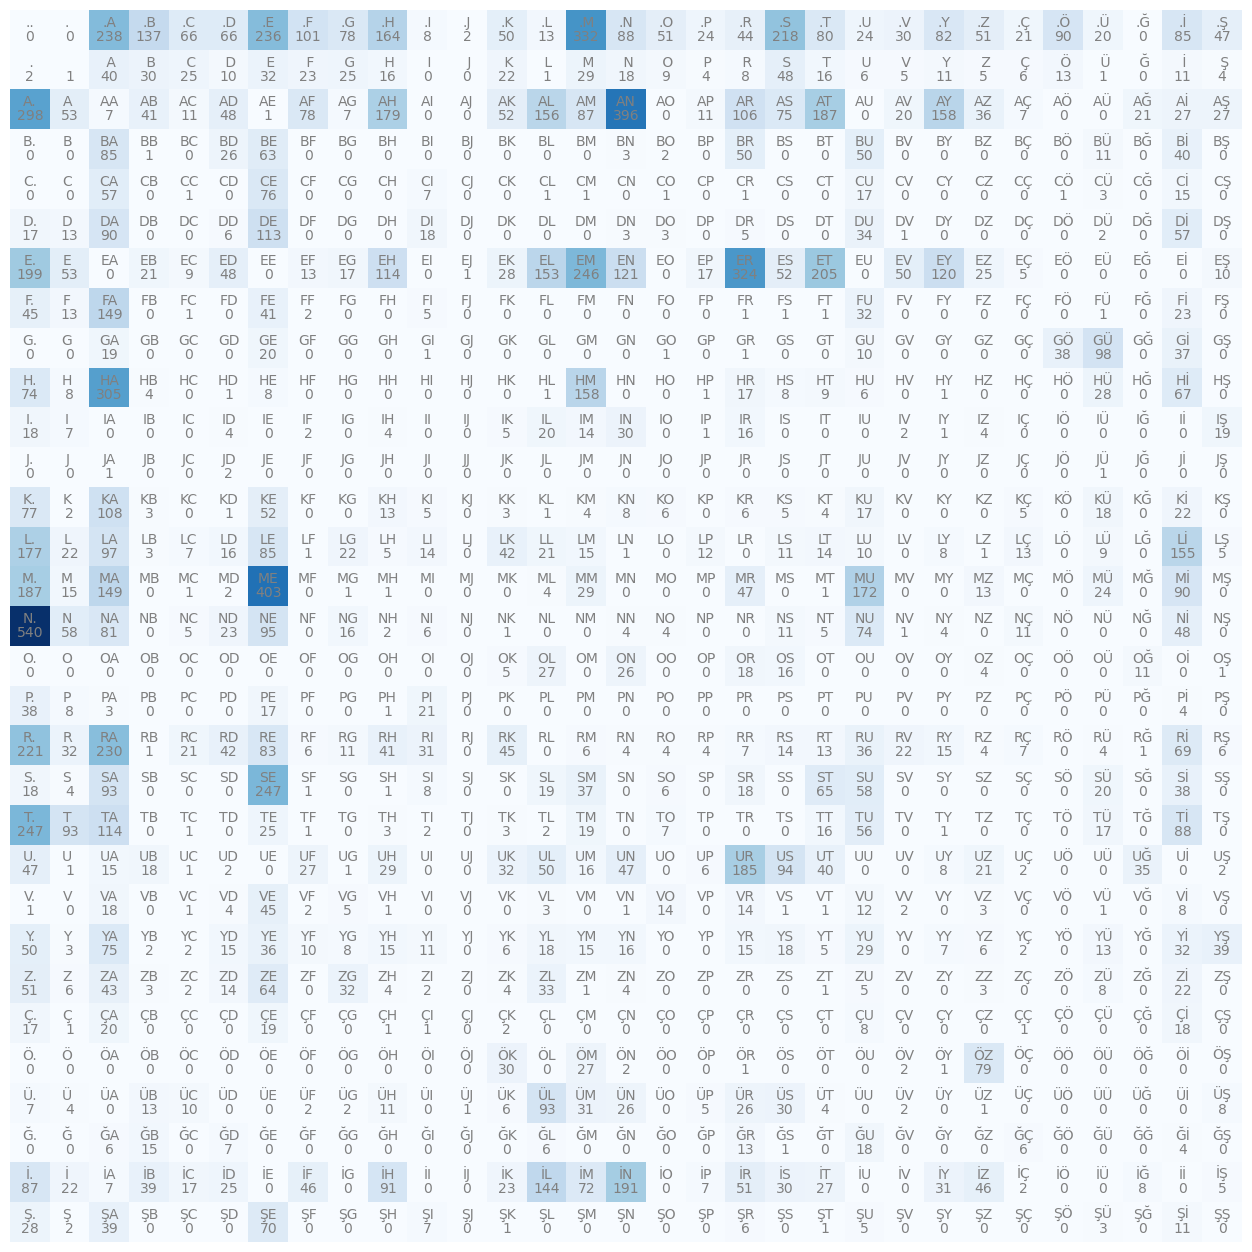

In [33]:
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(31):
    for j in range(31):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis('off')

In [12]:
P = N.float()
P = P / P.sum(1,keepdim=True)
torch.set_printoptions(sci_mode=False)
P

tensor([[    0.0000,     0.0000,     0.0973,     0.0560,     0.0270,     0.0270,
             0.0965,     0.0413,     0.0319,     0.0670,     0.0033,     0.0008,
             0.0204,     0.0053,     0.1357,     0.0360,     0.0209,     0.0098,
             0.0180,     0.0891,     0.0327,     0.0098,     0.0123,     0.0335,
             0.0209,     0.0086,     0.0368,     0.0082,     0.0000,     0.0348,
             0.0192],
        [    0.0048,     0.0024,     0.0950,     0.0713,     0.0594,     0.0238,
             0.0760,     0.0546,     0.0594,     0.0380,     0.0000,     0.0000,
             0.0523,     0.0024,     0.0689,     0.0428,     0.0214,     0.0095,
             0.0190,     0.1140,     0.0380,     0.0143,     0.0119,     0.0261,
             0.0119,     0.0143,     0.0309,     0.0024,     0.0000,     0.0261,
             0.0095],
        [    0.1427,     0.0254,     0.0034,     0.0196,     0.0053,     0.0230,
             0.0005,     0.0373,     0.0034,     0.0857,     0.00

(-0.5, 30.5, 30.5, -0.5)

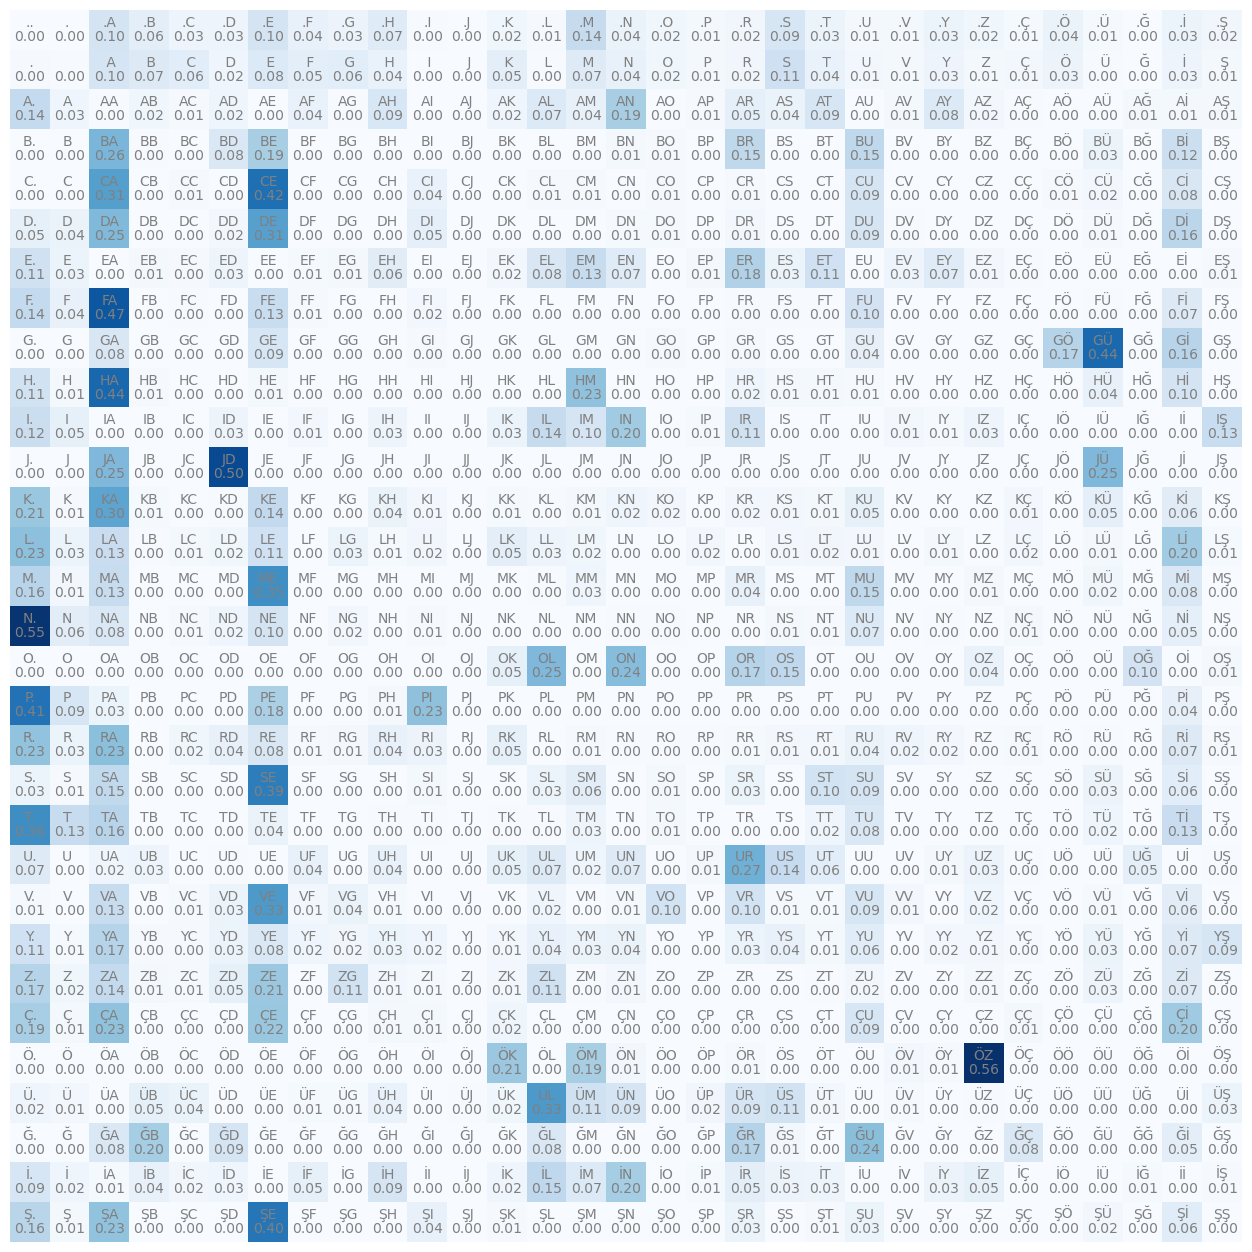

In [15]:
plt.figure(figsize=(16,16))
plt.imshow(P,cmap='Blues')
for i in range(31):
    for j in range(31):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, f'{P[i,j].item():.2f}', ha="center", va="top", color="gray")
plt.axis('off')

In [36]:
g = torch.Generator().manual_seed(1)

for i in range(10):
    ix = 0 
    out = []
    while True:
        
        p = P[ix]
        #p = p / p.sum() #inefficent
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

E.
CURAS.
DİLABUFEGÜHA ŞAT MİM MMAT.
MEL.
ERAA.
EBUZÜMÜSEBİT İZEDUR.
A.
VVERRUSERKAHALD.
SERAN.
CULI.


In [19]:
log_liklehood = 0.0
n = 0

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        prob = P[ch1_idx,ch2_idx]
        loss = torch.log(prob) * -1
        log_liklehood += loss
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} : {loss:.4f}')
        
print(f'log_liklehood Average = {log_liklehood / n}')

# Neden Maximum Liklehood kullanıldı? Neden Loss = 1 - P(gerçek sonraki karakter | mevcut karakter) kullanılması?
# Loss = -log(P(gerçek sonraki karakter | mevcut karakter))
# Bunu datanın tamamına entegre etmemiz gerekli ki modelin loss'unu tam olarak ölçebilelim

# log(a*b*c) = log(a) + log(b) + log(c)


log_liklehood Average = 2.35408091545105


In [20]:
xs, ys = [], []

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        
        xs.append(ch1_idx)
        ys.append(ch2_idx)
    

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()

xs,ys,num

(tensor([ 0, 11,  2,  ..., 28,  2, 15]),
 tensor([11,  2, 13,  ...,  2, 15,  0]),
 18108)

In [27]:
xs.shape

torch.Size([18108])

In [24]:
import torch.nn.functional as F

In [29]:
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((31,31),generator=g, requires_grad=True)

for i in range(100):
    
    x_enc = F.one_hot(xs, num_classes=31).float()
    logits = x_enc @ w # (5,27) * (27,27) = (5,27)
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdim=True)

    probs[torch.arange(num),ys]
    loss = -torch.log(probs[torch.arange(num),ys]).mean()
    print(loss.item())
    
    w.grad = None
    loss.backward()
    w.data += -50 * w.grad

3.8130877017974854
3.4453580379486084
3.2086997032165527
3.04970645904541
2.938779592514038
2.8595547676086426
2.800896406173706
2.7556331157684326
2.7193872928619385
2.6894233226776123
2.6640477180480957
2.6421873569488525
2.623124361038208
2.6063475608825684
2.5914719104766846
2.578197717666626
2.5662825107574463
2.5555291175842285
2.545774459838867
2.536882162094116
2.528740406036377
2.521254301071167
2.5143449306488037
2.507946491241455
2.5020036697387695
2.496469020843506
2.491302728652954
2.4864702224731445
2.4819424152374268
2.477691888809204
2.473695993423462
2.4699339866638184
2.4663877487182617
2.4630398750305176
2.4598758220672607
2.456881523132324
2.4540438652038574
2.451352119445801
2.4487953186035156
2.446364402770996
2.444049596786499
2.4418437480926514
2.4397389888763428
2.4377286434173584
2.4358065128326416
2.433967113494873
2.4322049617767334
2.430515766143799
2.428894281387329
2.427337408065796
2.425840377807617
2.424400806427002
2.4230148792266846
2.421679973602295
